In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, RFE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

import shap

from PyALE import ale

import joblib

E:\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Block 1. Data Preparation

# Task 1. Load the Dataset

In [2]:
df = sns.load_dataset('titanic')

# Display first 5 rows

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Display shape

In [4]:
df.shape

(891, 15)

# Display column names

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

# Display column types

In [6]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

# Task 2. Exploratory Data Analysis (EDA)

# Check missing values

In [7]:
missing = df.isna().sum()
missing_counts = pd.DataFrame({
    "count": missing,
    "percent": ((missing / len(df))*100).round(2).map(lambda x: f"{x}%") 
}).sort_values(by="count", ascending = False)
missing_counts

,count,percent
deck,688,77.22%
age,177,19.87%
embarked,2,0.22%
embark_town,2,0.22%
sex,0,0.0%
pclass,0,0.0%
survived,0,0.0%
fare,0,0.0%
parch,0,0.0%
sibsp,0,0.0%


# Show numerical feature statistics

In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Display class distribution.

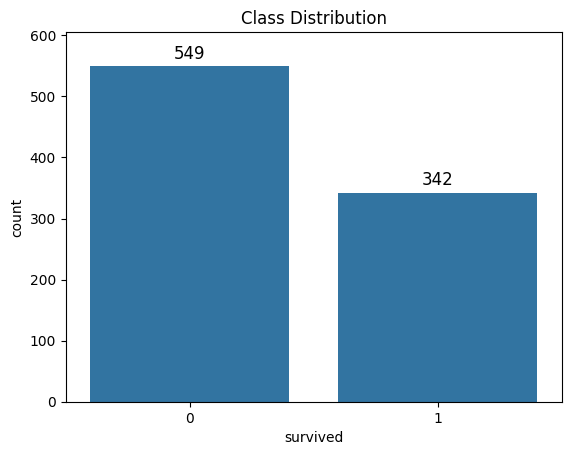

In [9]:
ax = sns.countplot(data = df, x = "survived")
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("Class Distribution")

plt.show()

# Display age distribution

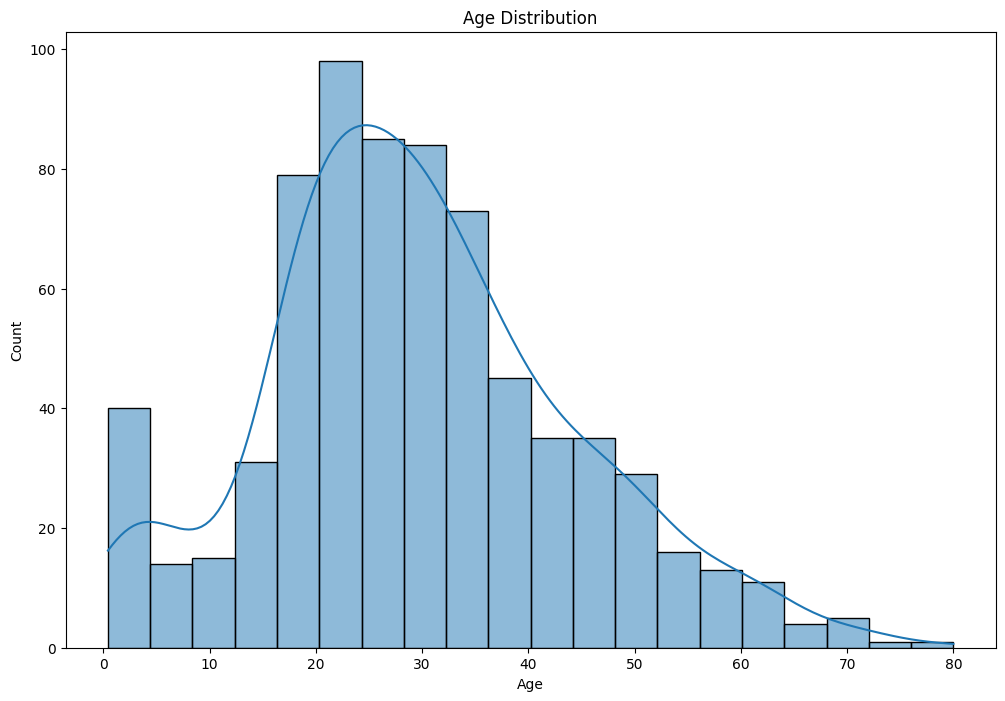

In [10]:
plt.figure(figsize = (12, 8))
sns.histplot(data = df, x = 'age', bins = 20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# Display correlation heatmap

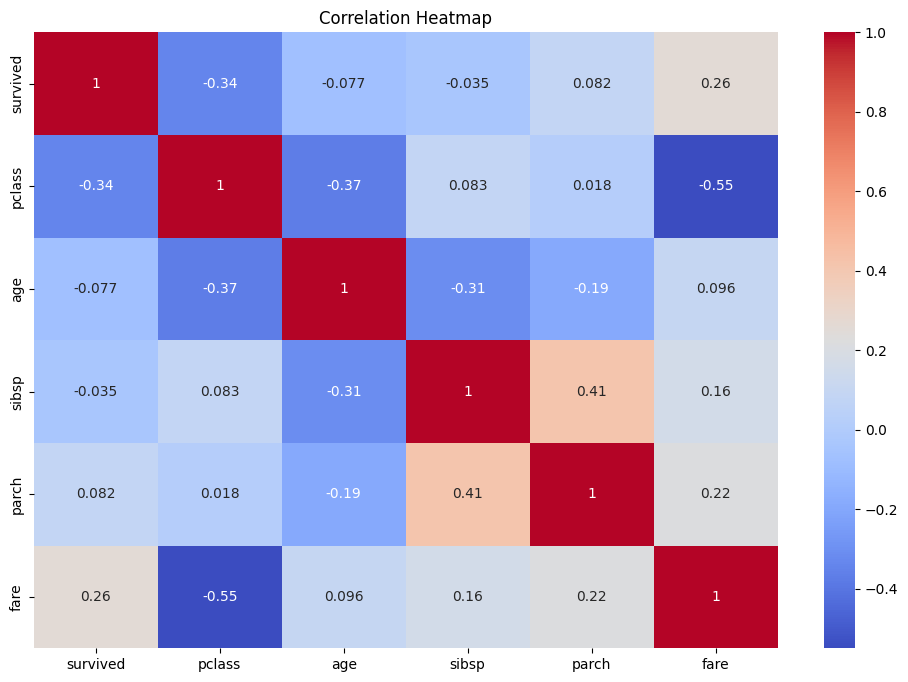

In [11]:
plt.figure(figsize = (12, 8))
data = df.select_dtypes(include="number").corr()
sns.heatmap(data, cmap = "coolwarm", annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Task 3. Data Cleaning

# Remove unnecessary columns

In [12]:
# class duplicates pclass
# who can be inferred from sex and age
# embark_town duplicates embarked
# alive duplicates survived
# deck contains too many missing values(77.2%)
df.drop(["class", "who", "embark_town", "alive", "deck"], axis = 1, inplace = True)

# Task 4. Feature Engineering

# Create new features

In [13]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["family_size"] = df["sibsp"] + df["parch"] + 1
    df["isChild"] = (df["age"] < 18).astype(int)
    df["fare_per_person"] = df["fare"] / df["family_size"]

    return df
df = feature_engineering(df)

# Block 2. Feature Selection

# Task 5. Low Variance Feature Analysis

In [14]:
X = df.drop("survived", axis = 1)
X_encoded = X.fillna({
    "age": X.age.median(),
    "embarked": X.embarked.mode()[0]
})
X_encoded = pd.get_dummies(X_encoded, drop_first=True)
y = df["survived"] 

selector = VarianceThreshold(threshold = 0.01).fit(X_encoded) 
selected_features = X_encoded.columns[selector.get_support()] 

feature_variance = pd.DataFrame({ 
    "feature": X_encoded.columns, 
    "variance": selector.variances_ 
}).sort_values(by = "variance", ascending = False) 

print("Original features:", len(df.columns) - 1) 
print("Selected features:", len(selected_features)) 
print(selected_features.tolist())
feature_variance

Original features: 12
Selected features: 13
['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'family_size', 'isChild', 'fare_per_person', 'sex_male', 'embarked_Q', 'embarked_S']


,feature,variance
4,fare,2466.665312
9,fare_per_person,1283.153979
1,age,169.322249
7,family_size,2.600327
2,sibsp,1.214678
0,pclass,0.698231
3,parch,0.648999
5,adult_male,0.239454
6,alone,0.239454
10,sex_male,0.228218


# Task 6. Mutual Information

In [15]:
X_encoded = X.fillna({
    "age": X.age.median(),
    "embarked": X.embarked.mode()[0]
})
X_encoded = pd.get_dummies(X_encoded, drop_first=True)

selector = SelectKBest(score_func = mutual_info_classif, k = 10).fit(X_encoded, y)
selected_features = X_encoded.columns[selector.get_support()]
feature_score = pd.DataFrame({
    "feature": X_encoded.columns,
    "score": selector.scores_
}).sort_values(by = "score", ascending = False)
print("Original features:", len(df.columns) - 1)
print("Selected features:", len(selected_features))
print(selected_features.tolist())
feature_score

Original features: 12
Selected features: 10
['pclass', 'age', 'fare', 'adult_male', 'alone', 'family_size', 'isChild', 'fare_per_person', 'sex_male', 'embarked_S']


,feature,score
5,adult_male,0.152135
9,fare_per_person,0.149231
10,sex_male,0.144507
4,fare,0.136404
0,pclass,0.060079
1,age,0.033754
7,family_size,0.030931
12,embarked_S,0.023915
6,alone,0.017123
8,isChild,0.016629


# Task 7. Split the Dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

# Block 3. Model Training

# Task 8. Build and Train Machine Learning Pipelines

In [39]:
num_cols = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person",
]

cat_cols = [
    "sex",
    "embarked",
]

bool_cols = [
    "adult_male",
    "alone",
    "isChild",
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy = "median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

boolean_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
    ("bool", boolean_transformer, bool_cols)
])

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42),
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

for pipeline in pipelines.values():
    pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 337
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

# Evaluate models

In [18]:
results = []
for name, pipeline in pipelines.items():
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
results = pd.DataFrame(results)
results

E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.826816,0.787879,0.753623,0.770370,0.865481
1,Random Forest,0.793296,0.728571,0.739130,0.733813,0.853689
2,XGBoost,0.804469,0.736111,0.768116,0.751773,0.854875
3,LightGBM,0.793296,0.710526,0.782609,0.744828,0.848353


# Task 9. Hyperparameter Tuning

In [19]:
params = {"model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) 

grid = GridSearchCV(estimator = pipelines['Random Forest'], param_grid = params, n_jobs = -1, scoring = 'roc_auc', cv = cv, verbose = 2).fit(X_train, y_train)

print("Best params", grid.best_params_)
print("Best score", grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best score 0.8733078565171042


# Task 10. Feature Importance

# Random Forest

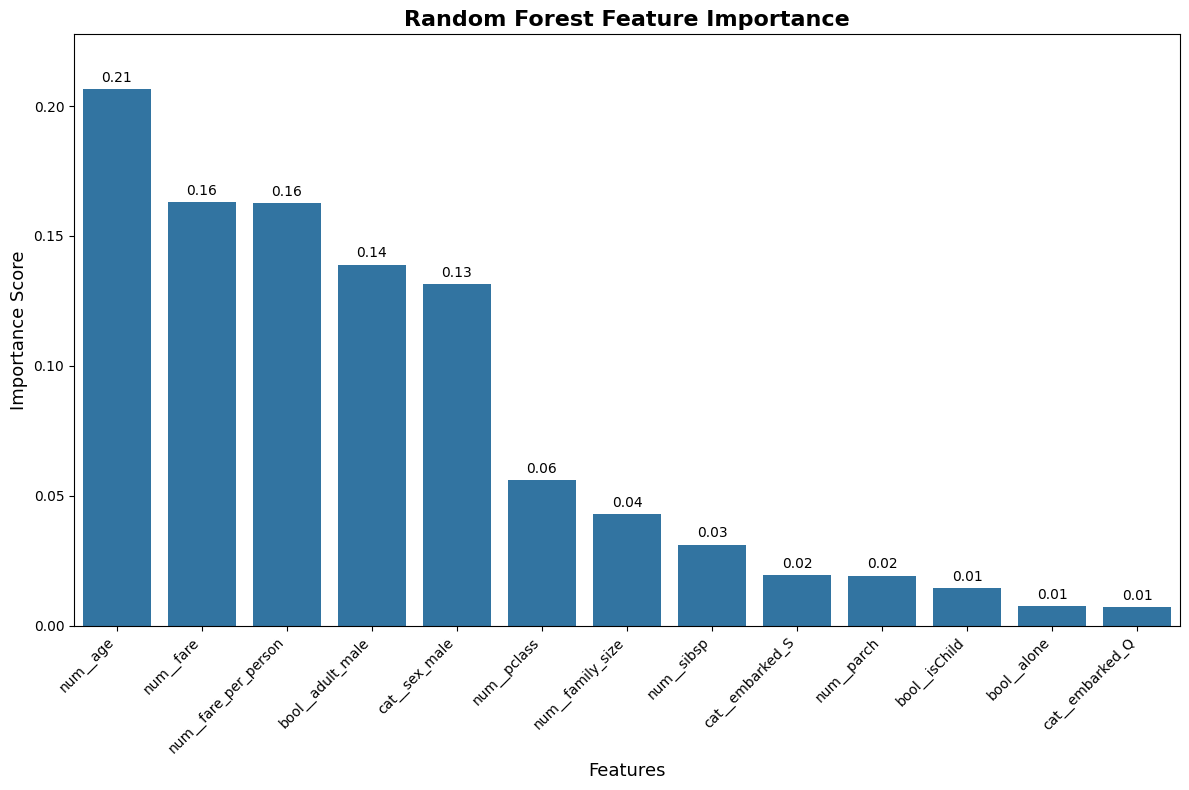

In [20]:
plt.figure(figsize = (12, 8))

rf_model = pipelines["Random Forest"].named_steps["model"]
feature_names = pipelines["Random Forest"].named_steps["preprocessor"].get_feature_names_out()

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by = "importance", ascending = False)
ax = sns.barplot(data = rf_importance, x = "feature", y = "importance")

for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("Random Forest Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Importance Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# XGBClassifier

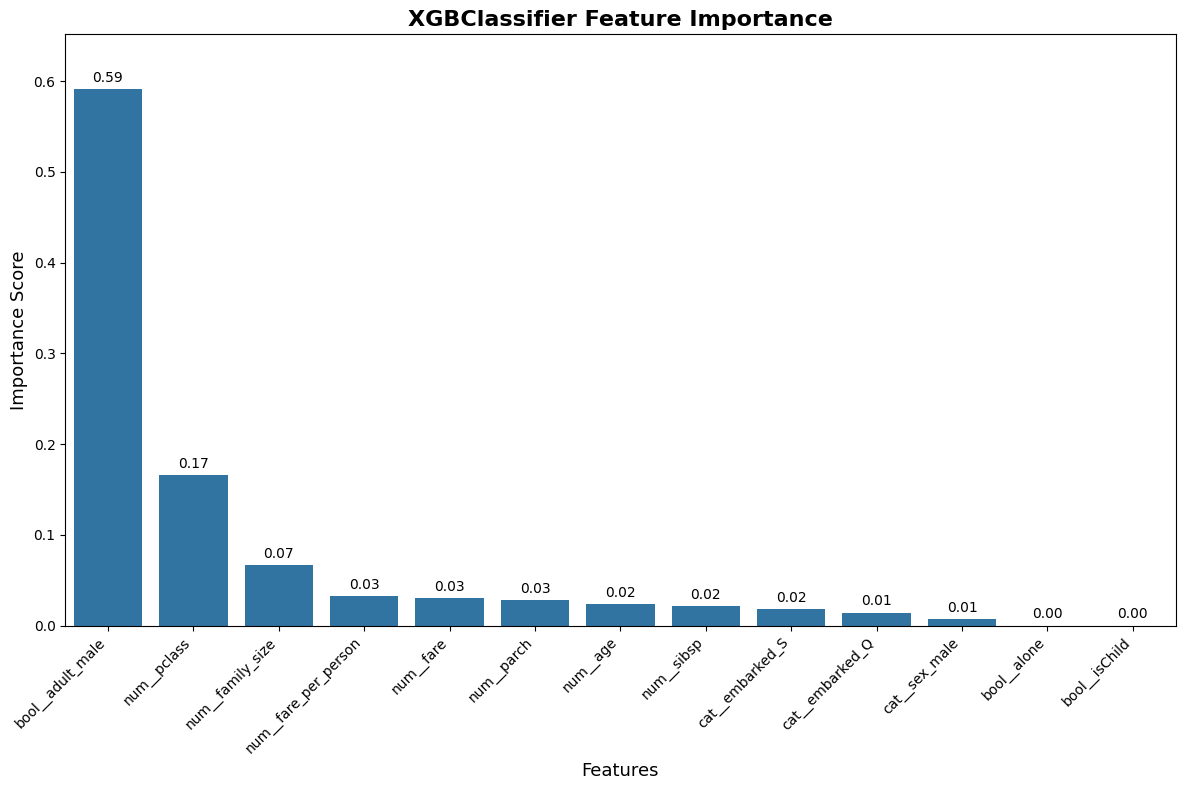

In [21]:
plt.figure(figsize = (12, 8))

xgb_model = pipelines["XGBoost"].named_steps["model"]
feature_names = pipelines["XGBoost"].named_steps["preprocessor"].get_feature_names_out()

xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values(by = "importance", ascending = False)
ax = sns.barplot(data = xgb_importance, x = "feature", y = "importance")

for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("XGBClassifier Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Importance Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# LGBMClassifier

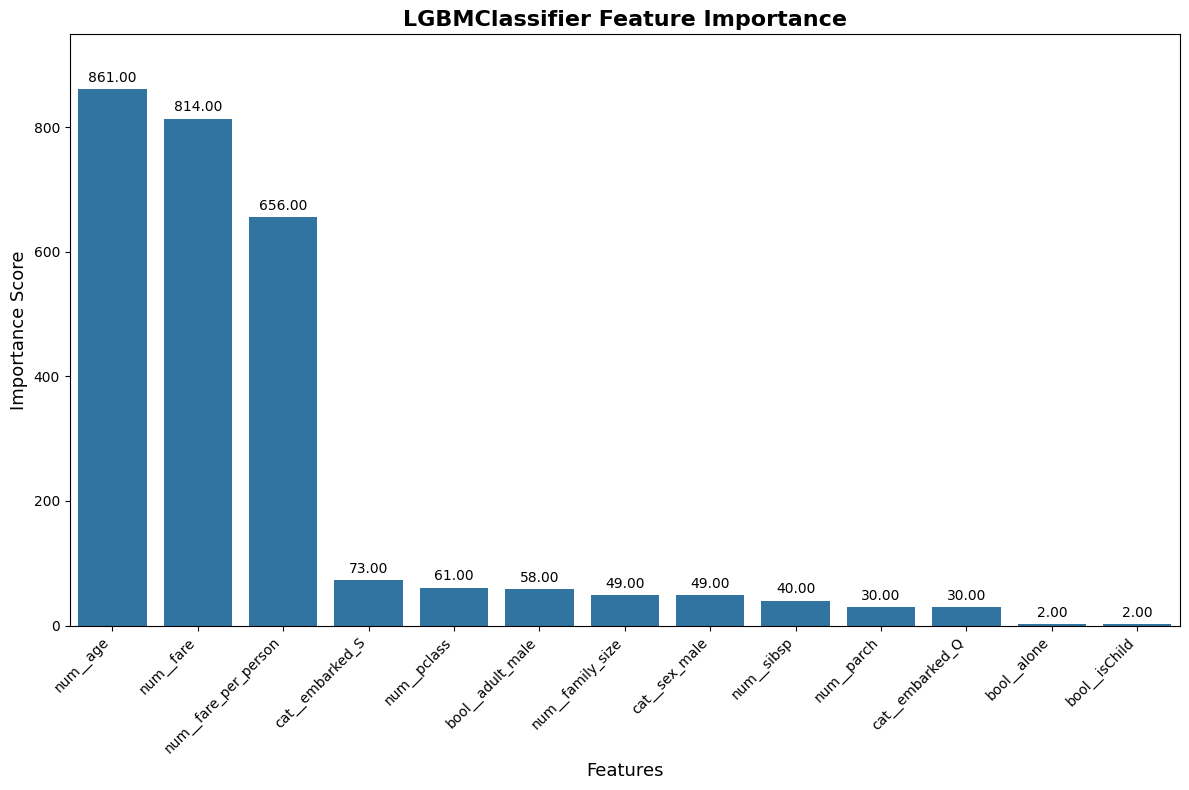

In [22]:
plt.figure(figsize = (12, 8))

lgbm_model = pipelines["LightGBM"].named_steps["model"]
feature_names = pipelines["LightGBM"].named_steps["preprocessor"].get_feature_names_out()

lgbm_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_model.feature_importances_
}).sort_values(by = "importance", ascending = False)
ax = sns.barplot(data = lgbm_importance, x = "feature", y = "importance")

for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("LGBMClassifier Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Importance Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Compare Feature Rankings using RFE

In [23]:
preprocessor = pipelines["XGBoost"].named_steps["preprocessor"]

X_train_processed = pd.DataFrame(
    preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

selector_1 = RFE(estimator = rf_model, n_features_to_select = 5).fit(X_train_processed, y_train)
selector_2 = RFE(estimator = xgb_model, n_features_to_select = 5).fit(X_train_processed, y_train)
selector_3 = RFE(estimator = lgbm_model, n_features_to_select = 5).fit(X_train_processed, y_train)

ran_for_clas_top_5 = feature_names[selector_1.get_support()]
xgb_class_top_5 = feature_names[selector_2.get_support()]
lgbm_clas_top_5 = feature_names[selector_3.get_support()]

print("Random Forest top5:", ran_for_clas_top_5)
print("XGBClassifier top5:", xgb_class_top_5)
print("LGBMClassifier top5:", lgbm_clas_top_5)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 337
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# Calculate permutation importance

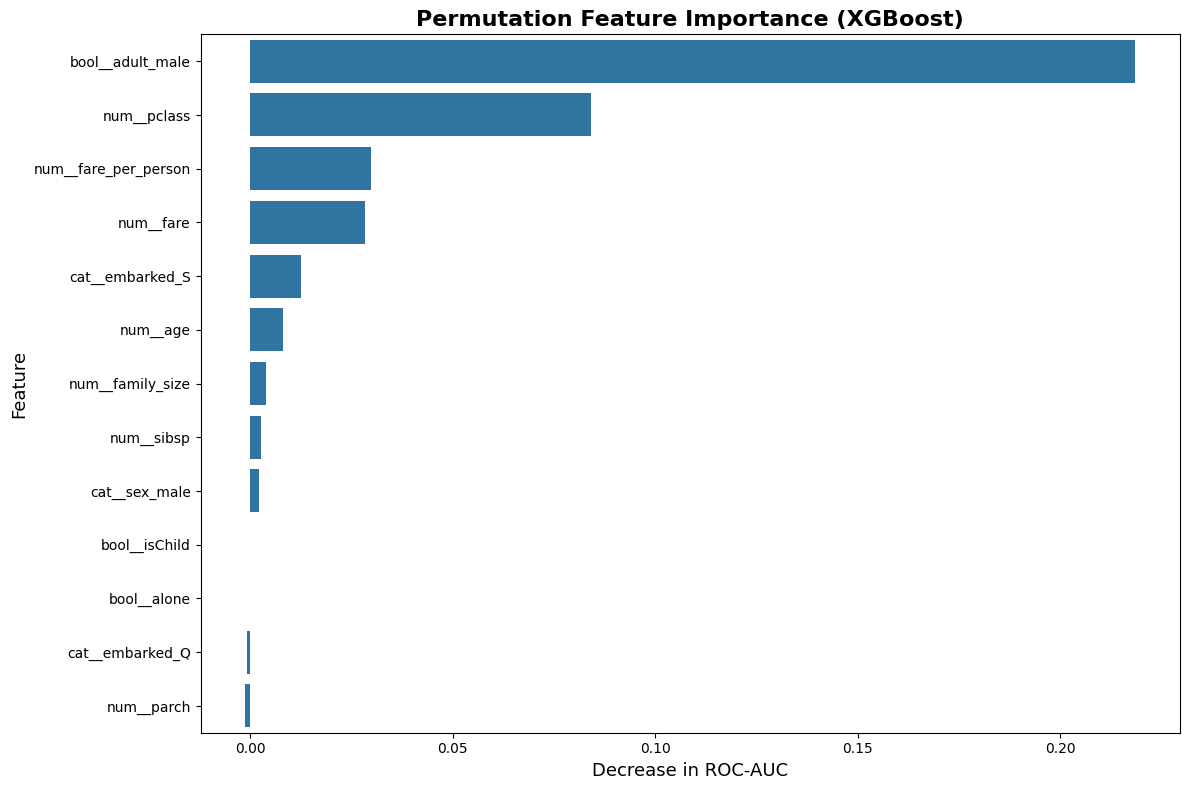

In [24]:
plt.figure(figsize = (12, 8))
perm = permutation_importance(xgb_model, X_test_processed, y_test, scoring = "roc_auc", n_repeats = 20, random_state = 42)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by = 'importance', ascending = False)

sns.barplot(data = perm_df, x="importance", y="feature")

plt.title(
    "Permutation Feature Importance (XGBoost)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Decrease in ROC-AUC", fontsize=13)
plt.ylabel("Feature", fontsize=13)

plt.tight_layout()
plt.show()

# Block 4. Global Explainability

# Task 11. SHAP Explainer

In [41]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_processed)
print(shap_values)

.values =
array([[-0.8020597 ,  0.26396427,  0.05981789, ...,  2.0698378 ,
         0.        ,  0.        ],
       [ 0.12304938,  0.02778987, -0.03877021, ..., -1.292869  ,
         0.        ,  0.        ],
       [-1.0154601 ,  0.27966005,  0.11294237, ...,  1.5953119 ,
         0.        ,  0.        ],
       ...,
       [-0.42656738,  0.5243575 ,  0.06821322, ..., -1.2961116 ,
         0.        ,  0.        ],
       [-0.40309078,  1.0580546 ,  0.1135997 , ..., -0.7784021 ,
         0.        ,  0.        ],
       [-0.29157913, -0.37110296,  0.0490095 , ..., -1.1728837 ,
         0.        ,  0.        ]], shape=(179, 13), dtype=float32)

.base_values =
array([-0.5497112, -0.5497112, -0.5497112, -0.5497112, -0.5497112,
       -0.5497112, -0.5497112, -0.5497112, -0.5497112, -0.5497112,
       -0.5497112, -0.5497112, -0.5497112, -0.5497112, -0.5497112,
       -0.5497112, -0.5497112, -0.5497112, -0.5497112, -0.5497112,
       -0.5497112, -0.5497112, -0.5497112, -0.5497112, -0.549

# Task 12. SHAP Summary Plot

C:\Users\PK1\AppData\Local\Temp\ipykernel_9384\1125373684.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, show = False, feature_names = feature_names)


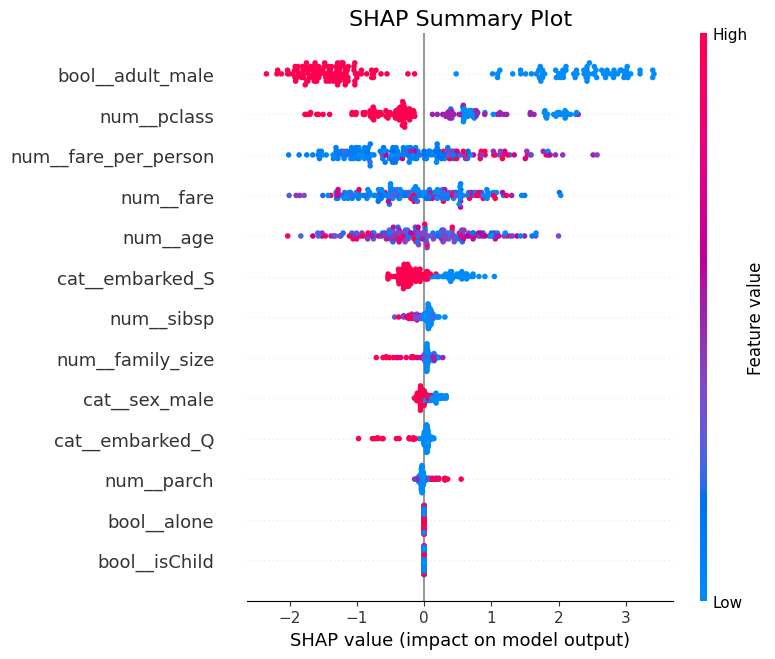

In [42]:
plt.figure(figsize = (12, 8))
shap.summary_plot(shap_values, show = False, feature_names = feature_names)

plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

# Task 13. SHAP Dependence Plot

<Figure size 1200x800 with 0 Axes>

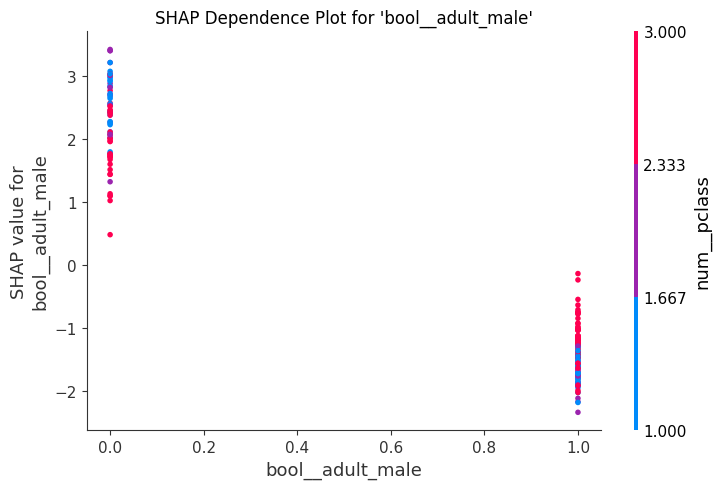

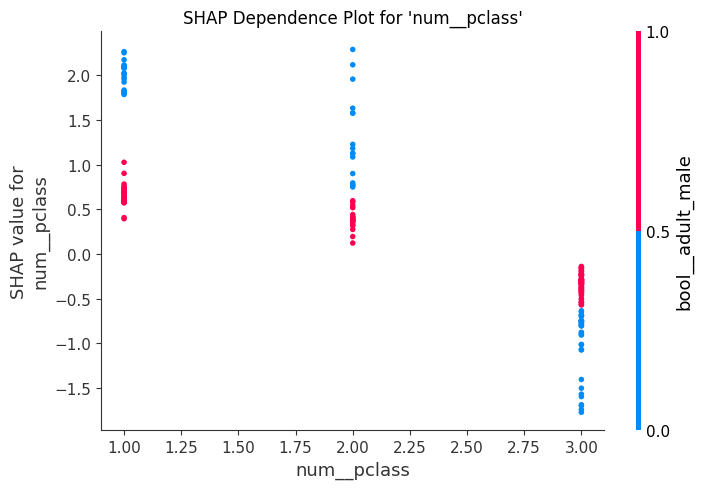

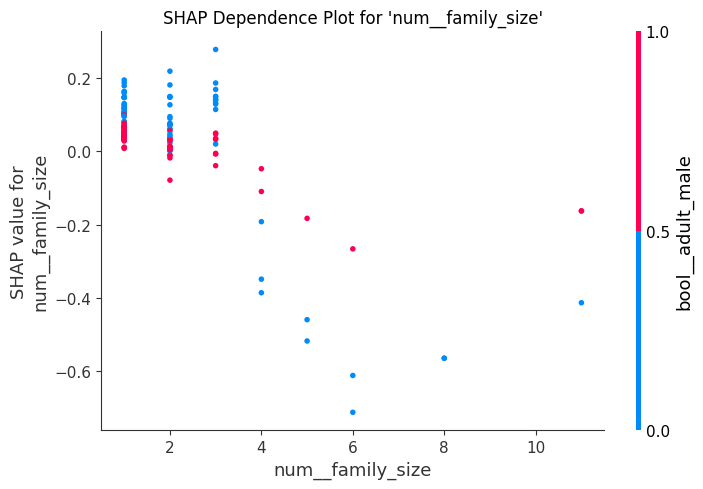

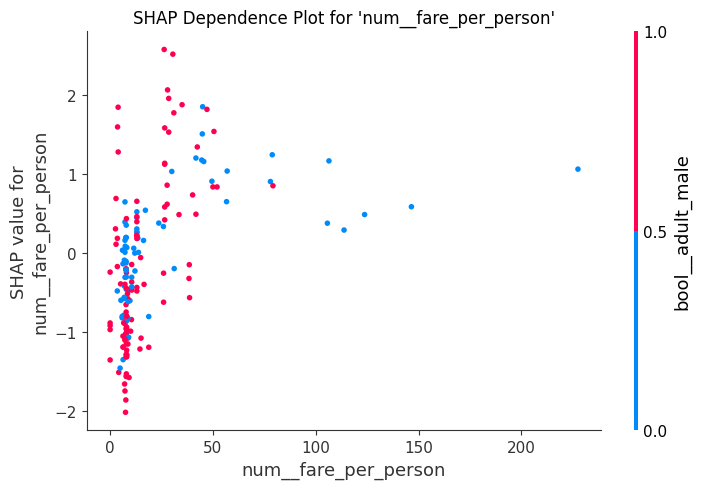

In [43]:
plt.figure(figsize = (12, 8))
top_features = xgb_importance["feature"].head(4)
for feature in top_features:
    shap.dependence_plot(feature, shap_values.values, X_test_processed, show = False)

    plt.title(f"SHAP Dependence Plot for '{feature}'")
    plt.tight_layout()
    plt.show()

# Task 14. SHAP Interaction Values

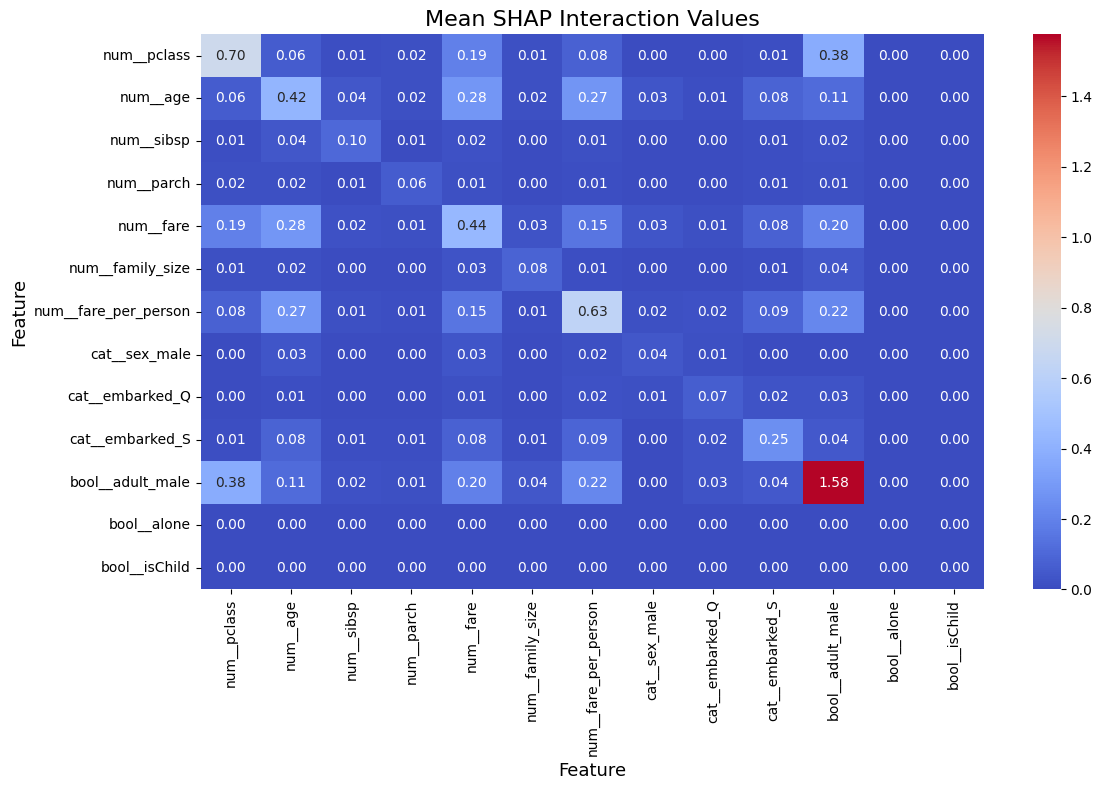

In [44]:
interaction_values = explainer.shap_interaction_values(X_test_processed)
interaction = np.abs(interaction_values).mean(axis = 0)
plt.figure(figsize=(12, 8))

sns.heatmap(
    interaction,
    xticklabels=feature_names,
    yticklabels=feature_names,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Mean SHAP Interaction Values", fontsize = 16)
plt.xlabel("Feature", fontsize = 13)
plt.ylabel("Feature", fontsize = 13)

plt.tight_layout()
plt.show()

# Task 15. Partial Dependence Plot

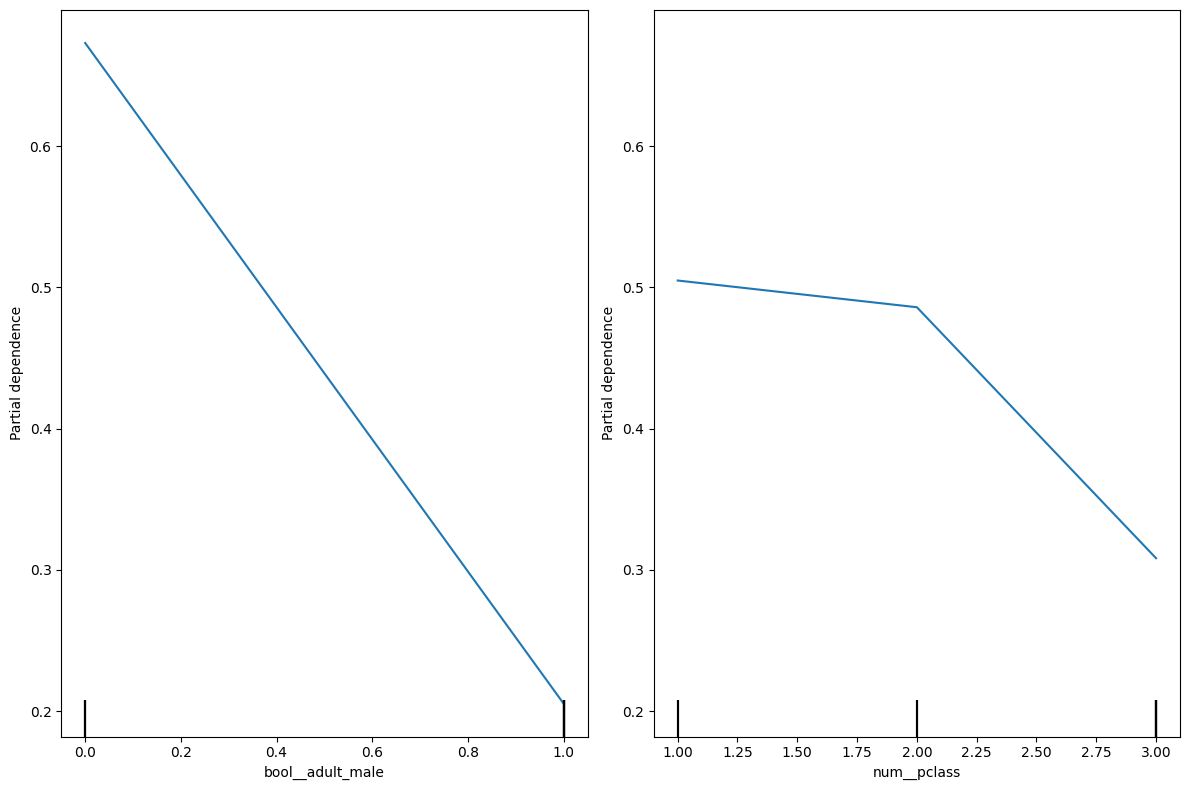

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(estimator=xgb_model, X=X_test_processed, features = xgb_importance["feature"].head(2).values, ax = ax)

plt.tight_layout()
plt.show()

# Task 16. ALE Plot

PyALE._ALE_generic:INFO: Continuous feature detected.


<Figure size 1200x600 with 0 Axes>

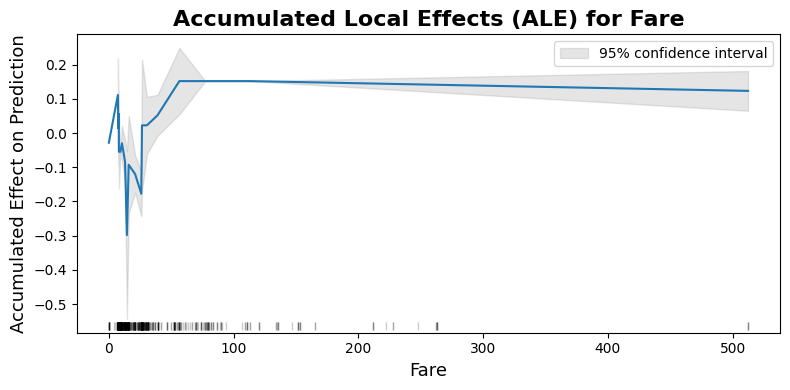

In [46]:
plt.figure(figsize=(12, 6))

ale(X = X_train_processed, model = xgb_model, feature = ["num__fare"], grid_size = 20, include_CI = True)

plt.title(
    "Accumulated Local Effects (ALE) for Fare",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fare", fontsize=13)
plt.ylabel("Accumulated Effect on Prediction", fontsize=13)

plt.tight_layout()
plt.show()

# Block 5. Local Explainability

# Task 17. SHAP Waterfall Plot

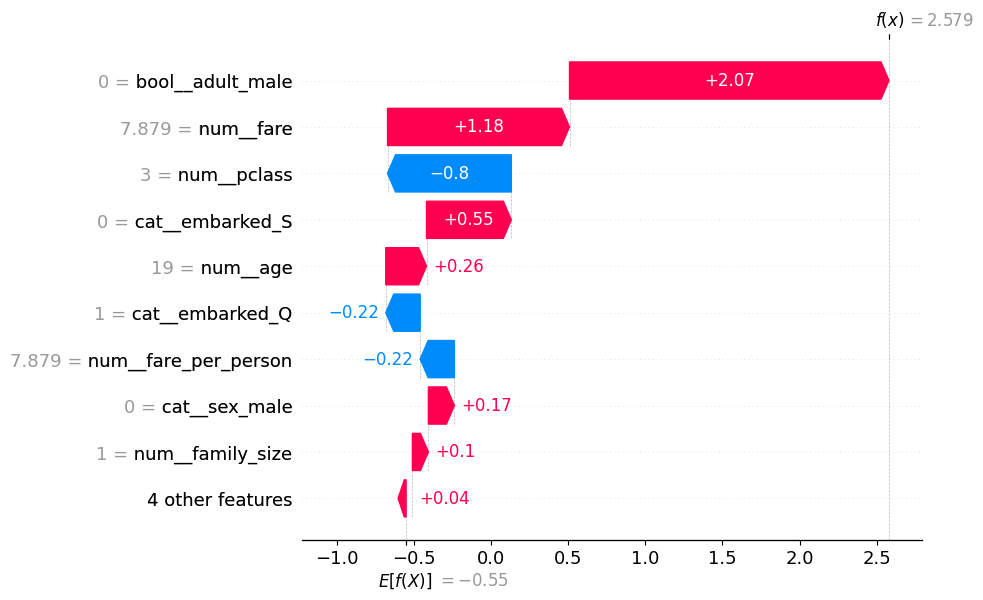

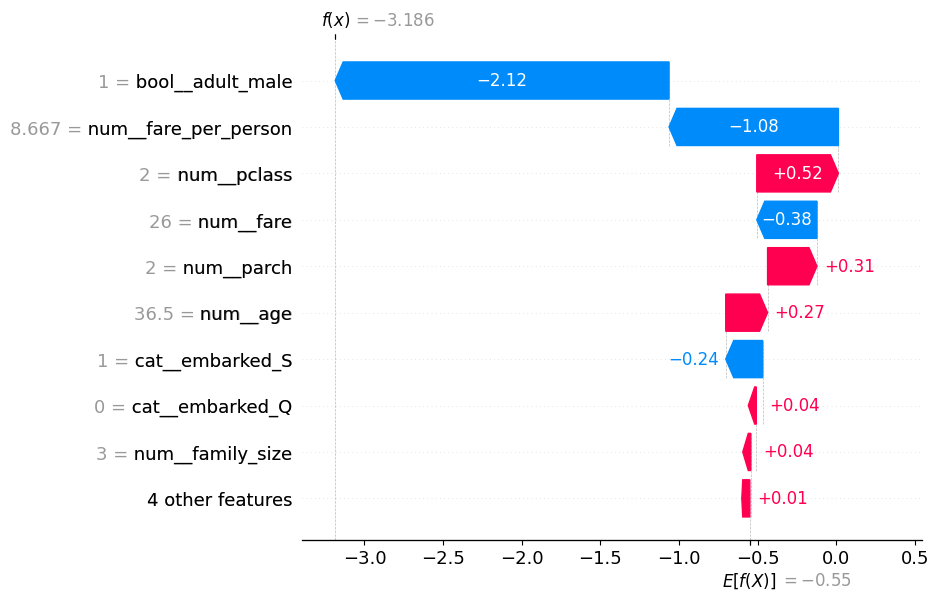

In [49]:
pred = pipelines["XGBoost"].predict(X_test)

correct_pos = np.where(pred == y_test)[0][0]
wrong_pos = np.where(pred != y_test)[0][0]

shap.plots.waterfall(shap_values[correct_pos])
shap.plots.waterfall(shap_values[wrong_pos])

# Task 18. SHAP Force Plot

In [50]:
correct_pos = np.where(pred == y_test)[0][0]
print("Correct prediction")
shap.plots.force(shap_values[correct_pos])

Correct prediction


In [51]:
wrong_pos = np.where(pred != y_test)[0][0]
print("Wrong prediction")
shap.plots.force(shap_values[wrong_pos])

Wrong prediction


# Task 19. SHAP Decision Plot

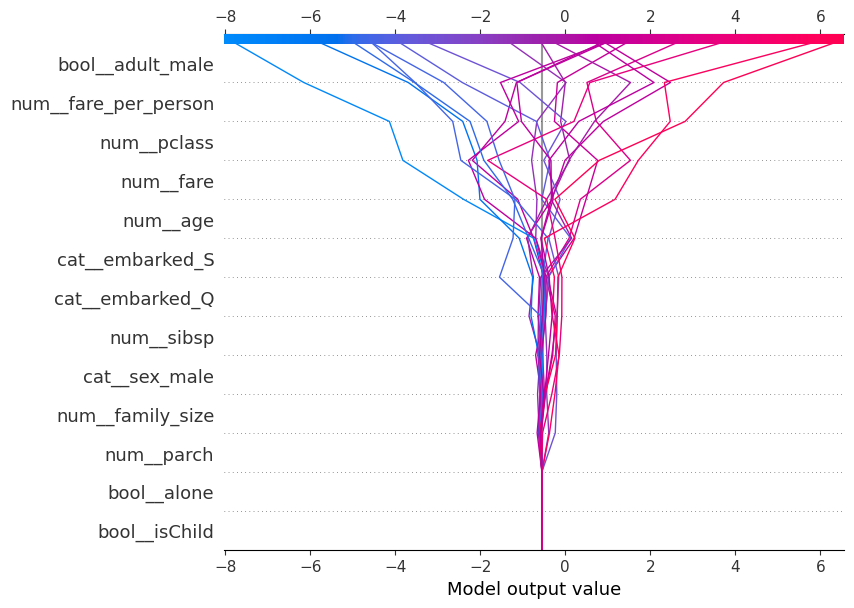

In [52]:
shap.decision_plot(shap_values.base_values[0],
                  shap_values.values[:20],
                  X_test_processed.iloc[:20],
                  feature_names)

In [35]:
joblib.dump(pipelines["XGBoost"], "E:/Python/Explainable_AI_Project/api/xgboost_pipeline.pkl")

['E:/Python/Explainable_AI_Project/api/xgboost_pipeline.pkl']

In [36]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone,family_size,isChild,fare_per_person
0,0,3,male,22.0,1,0,7.2500,S,True,False,2,0,3.62500
1,1,1,female,38.0,1,0,71.2833,C,False,False,2,0,35.64165
2,1,3,female,26.0,0,0,7.9250,S,False,True,1,0,7.92500
3,1,1,female,35.0,1,0,53.1000,S,False,False,2,0,26.55000
4,0,3,male,35.0,0,0,8.0500,S,True,True,1,0,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True,True,1,0,13.00000
887,1,1,female,19.0,0,0,30.0000,S,False,True,1,0,30.00000
888,0,3,female,NaN,1,2,23.4500,S,False,False,4,0,5.86250
889,1,1,male,26.0,0,0,30.0000,C,True,True,1,0,30.00000
